In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
from itertools import groupby
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.metrics import f1_score,confusion_matrix,classification_report
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn import tree
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')


## VERİ SETİ YÜKLEME VE HAZIRLIK

In [4]:
data= pd.read_csv("C:/Users/HP/Documents/data1.csv",sep= ";",decimal=",")

data.columns = data.columns.str.replace(" ","_")
tr_eng = str.maketrans("çğıöşü", "cgiosu")
data.columns = data.columns.str.lower().str.translate(tr_eng)

In [6]:
columns_rename = {
    'account_length': 'Üyelik_Süresi_Gün',
    'location_code': 'Lokasyon_Kodu',
    'user_id': 'Kullanıcı_ID',
    'credit_card_info_save': 'Kredi_Kartı_Kaydedildi',
    'push_status': 'Bildirim_İzni',
    'add_to_wishlist': 'İstek_Listesi_Sayısı',
    'desktop_sessions': 'Masaüstü_Oturum_Sayısı',
    'app_sessions': 'Uygulama_Oturum_Sayısı',
    'desktop_transactions': 'Masaüstü_Alışveriş_Sayısı',
    'total_product_detail_views': 'Ürün_Detay_Görüntüleme_Sayısı',
    'session_duration': 'Ortalama_Oturum_Süresi',
    'promotion_clicks': 'Promosyon_Tıklama_Sayısı',
    'avg_order_value': 'Ortalama_Sipariş_Değeri',
    'sale_product_views': 'İndirimli_Ürün_Görüntüleme_Sayısı',
    'discount_rate_per_visited_products': 'Ürün_Bazlı_İndirim_Oranı',
    'product_detail_view_per_app_session': 'Uygulama_Oturumu_Başına_Detay_Görüntüleme',
    'app_transactions': 'Uygulama_Alışveriş_Sayısı',
    'add_to_cart_per_session': 'Oturum_Başına_Sepete_Ekleme',
    'customer_service_calls': 'Müşteri_Hizmetleri_Arama_Sayısı',
    'churn': 'Churn_Hedef_Değişken'
}


## Veri Hazırlık Aşaması

#### Giriş

In [7]:
data = data.rename(columns=columns_rename)

In [8]:
# Evet/Hayır'ı 1/0 olarak değiştirme
for i in data.select_dtypes(include=['object']).columns.values:
    data[i] = data[i].replace(["yes", "no"], [1, 0])

# Kategorik ve sayısal sütunlar
categorical_columns = ["Lokasyon_Kodu", "Bildirim_İzni", "Kredi_Kartı_Kaydedildi"]
out_of_analyze = ["Kullanıcı_ID", "Churn_Hedef_Değişken"]
numeric_columns = [
    'Üyelik_Süresi_Gün', 'İstek_Listesi_Sayısı', 'Masaüstü_Oturum_Sayısı',
    'Uygulama_Oturum_Sayısı', 'Masaüstü_Alışveriş_Sayısı',
    'Ürün_Detay_Görüntüleme_Sayısı', 'Ortalama_Oturum_Süresi',
    'Promosyon_Tıklama_Sayısı', 'Ortalama_Sipariş_Değeri',
    'İndirimli_Ürün_Görüntüleme_Sayısı', 'Ürün_Bazlı_İndirim_Oranı',
    'Uygulama_Oturumu_Başına_Detay_Görüntüleme', 'Uygulama_Alışveriş_Sayısı',
    'Oturum_Başına_Sepete_Ekleme', 'Müşteri_Hizmetleri_Arama_Sayısı'
]


In [9]:
data.head()

,Üyelik_Süresi_Gün,Lokasyon_Kodu,Kullanıcı_ID,Kredi_Kartı_Kaydedildi,Bildirim_İzni,İstek_Listesi_Sayısı,Masaüstü_Oturum_Sayısı,Uygulama_Oturum_Sayısı,Masaüstü_Alışveriş_Sayısı,Ürün_Detay_Görüntüleme_Sayısı,Ortalama_Oturum_Süresi,Promosyon_Tıklama_Sayısı,Ortalama_Sipariş_Değeri,İndirimli_Ürün_Görüntüleme_Sayısı,Ürün_Bazlı_İndirim_Oranı,Uygulama_Oturumu_Başına_Detay_Görüntüleme,Uygulama_Alışveriş_Sayısı,Oturum_Başına_Sepete_Ekleme,Müşteri_Hizmetleri_Arama_Sayısı,Churn_Hedef_Değişken
0,128,415,3824657,0,1,25,265,45,17,110,197,87,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,3717191,0,1,26,162,27,17,123,196,103,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,3581921,0,0,0,243,41,10,114,121,110,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,3759999,1,0,0,299,51,5,71,62,88,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,3306626,1,0,0,167,28,13,113,148,122,186.9,121,8.41,10.1,3,2.73,3,0


In [10]:
data.shape

(3333, 20)

In [11]:
data.Churn_Hedef_Değişken.value_counts()

Churn_Hedef_Değişken
0    2850
1     483
Name: count, dtype: int64

In [12]:
data.Lokasyon_Kodu.value_counts()

Lokasyon_Kodu
415    1655
510     840
408     838
Name: count, dtype: int64

#### TİP  KONTROLÜ

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Üyelik_Süresi_Gün                          3333 non-null   int64  
 1   Lokasyon_Kodu                              3333 non-null   int64  
 2   Kullanıcı_ID                               3333 non-null   int64  
 3   Kredi_Kartı_Kaydedildi                     3333 non-null   int64  
 4   Bildirim_İzni                              3333 non-null   int64  
 5   İstek_Listesi_Sayısı                       3333 non-null   int64  
 6   Masaüstü_Oturum_Sayısı                     3333 non-null   int64  
 7   Uygulama_Oturum_Sayısı                     3333 non-null   int64  
 8   Masaüstü_Alışveriş_Sayısı                  3333 non-null   int64  
 9   Ürün_Detay_Görüntüleme_Sayısı              3333 non-null   int64  
 10  Ortalama_Oturum_Süresi  

#### EKSİK VERİ KONTROLÜ

In [14]:
# Her sütundaki eksik veri sayısını göster
missing_values = data.isnull().sum()
print(missing_values)


Üyelik_Süresi_Gün                            0
Lokasyon_Kodu                                0
Kullanıcı_ID                                 0
Kredi_Kartı_Kaydedildi                       0
Bildirim_İzni                                0
İstek_Listesi_Sayısı                         0
Masaüstü_Oturum_Sayısı                       0
Uygulama_Oturum_Sayısı                       0
Masaüstü_Alışveriş_Sayısı                    0
Ürün_Detay_Görüntüleme_Sayısı                0
Ortalama_Oturum_Süresi                       0
Promosyon_Tıklama_Sayısı                     0
Ortalama_Sipariş_Değeri                      0
İndirimli_Ürün_Görüntüleme_Sayısı            0
Ürün_Bazlı_İndirim_Oranı                     0
Uygulama_Oturumu_Başına_Detay_Görüntüleme    0
Uygulama_Alışveriş_Sayısı                    0
Oturum_Başına_Sepete_Ekleme                  0
Müşteri_Hizmetleri_Arama_Sayısı              0
Churn_Hedef_Değişken                         0
dtype: int64


#### Kullanıcı_ID

In [15]:
# Remove CustomerID column
data.drop(columns='Kullanıcı_ID', inplace=True)
data.head()

,Üyelik_Süresi_Gün,Lokasyon_Kodu,Kredi_Kartı_Kaydedildi,Bildirim_İzni,İstek_Listesi_Sayısı,Masaüstü_Oturum_Sayısı,Uygulama_Oturum_Sayısı,Masaüstü_Alışveriş_Sayısı,Ürün_Detay_Görüntüleme_Sayısı,Ortalama_Oturum_Süresi,Promosyon_Tıklama_Sayısı,Ortalama_Sipariş_Değeri,İndirimli_Ürün_Görüntüleme_Sayısı,Ürün_Bazlı_İndirim_Oranı,Uygulama_Oturumu_Başına_Detay_Görüntüleme,Uygulama_Alışveriş_Sayısı,Oturum_Başına_Sepete_Ekleme,Müşteri_Hizmetleri_Arama_Sayısı,Churn_Hedef_Değişken
0,128,415,0,1,25,265,45,17,110,197,87,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,162,27,17,123,196,103,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243,41,10,114,121,110,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299,51,5,71,62,88,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,167,28,13,113,148,122,186.9,121,8.41,10.1,3,2.73,3,0


#### Histogram

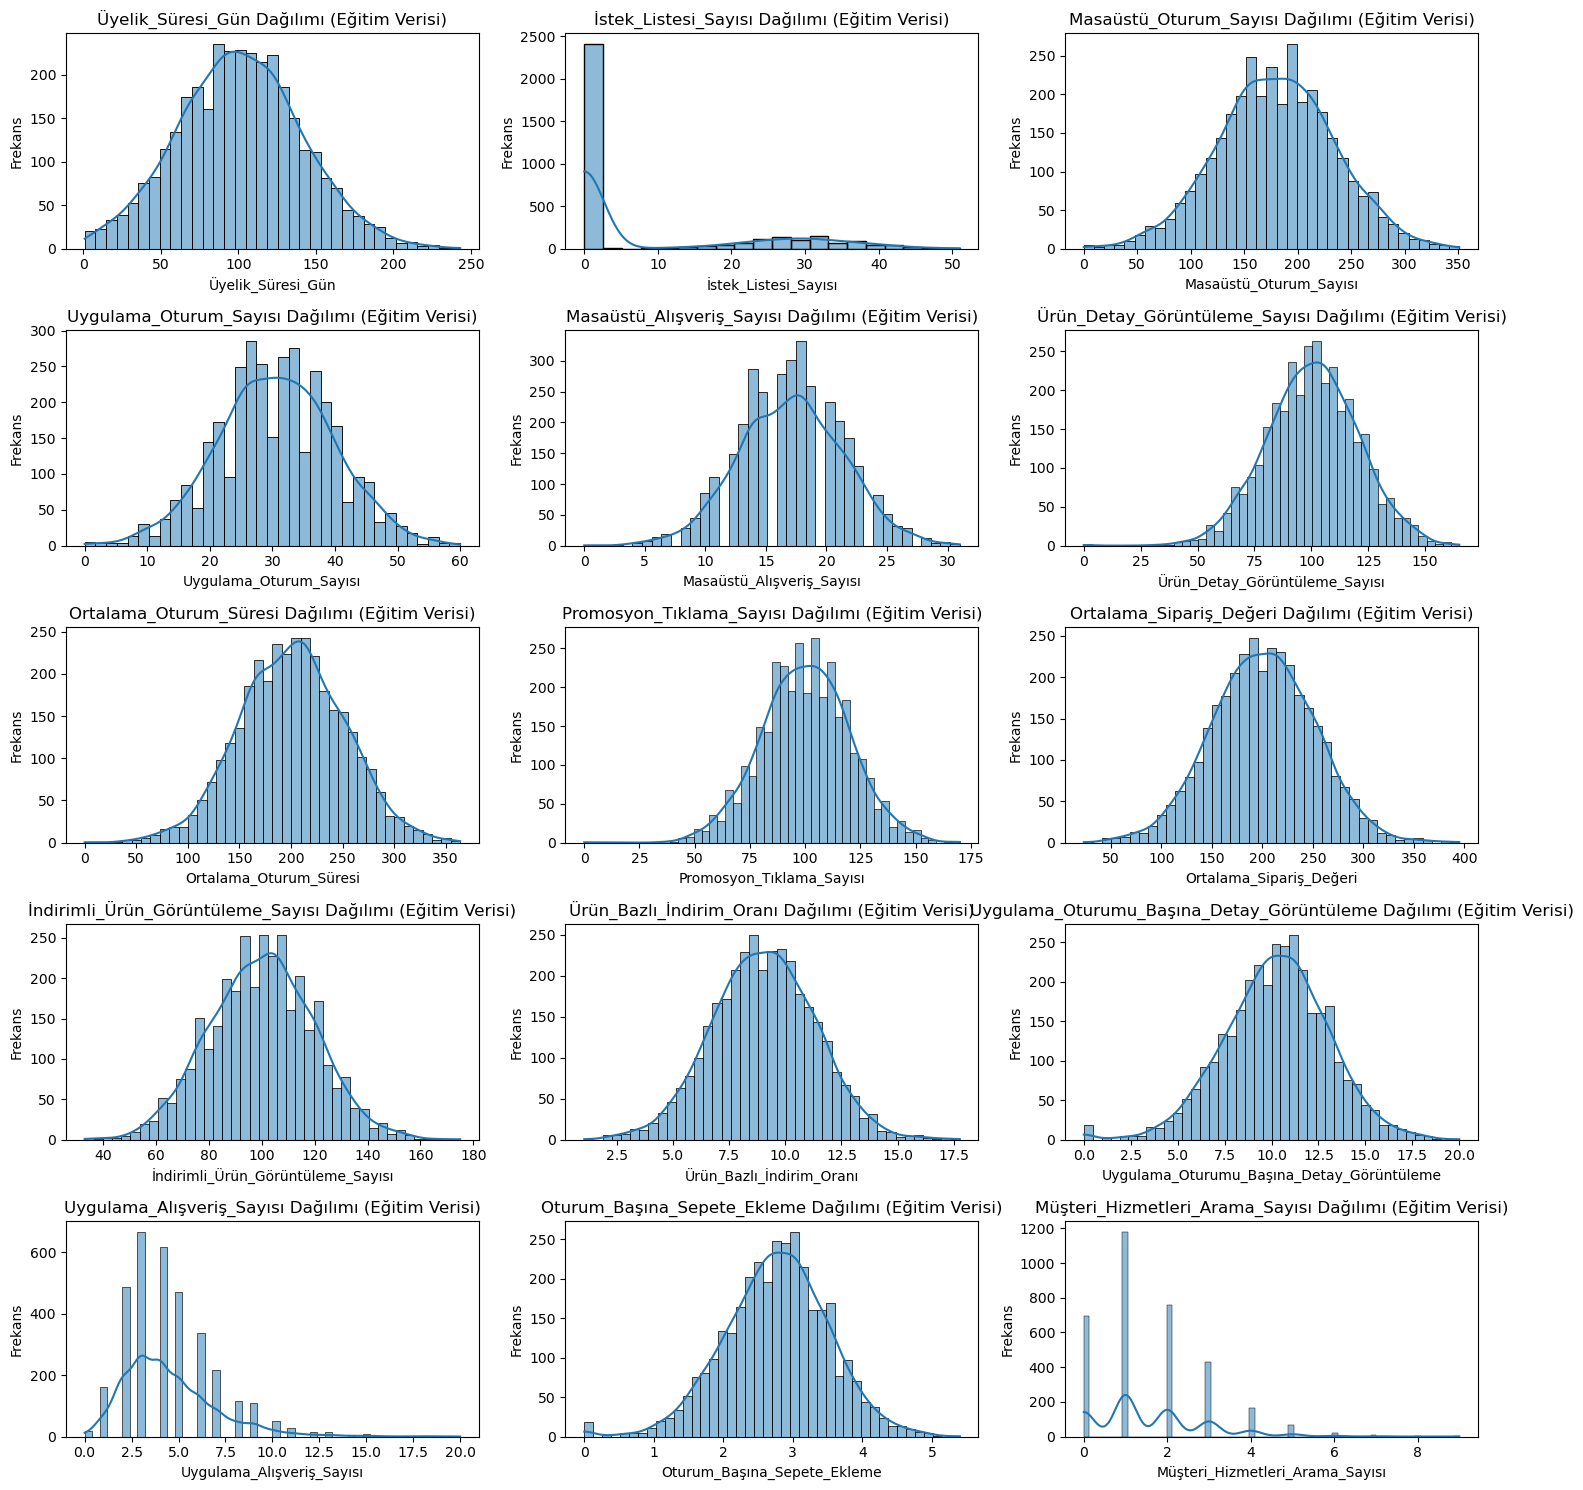

In [16]:
# Alt grafik düzeni (Histogram + KDE için - Eğitim Verisi)
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))
axs = axs.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data[column], kde=True, ax=axs[i])  # Eğitim verisini kullanıyoruz
    axs[i].set_title(f'{column} Dağılımı (Eğitim Verisi)')
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Frekans')

# Kalan boş alt grafikleri temizle
for j in range(len(numeric_columns), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()



#### Boxplot

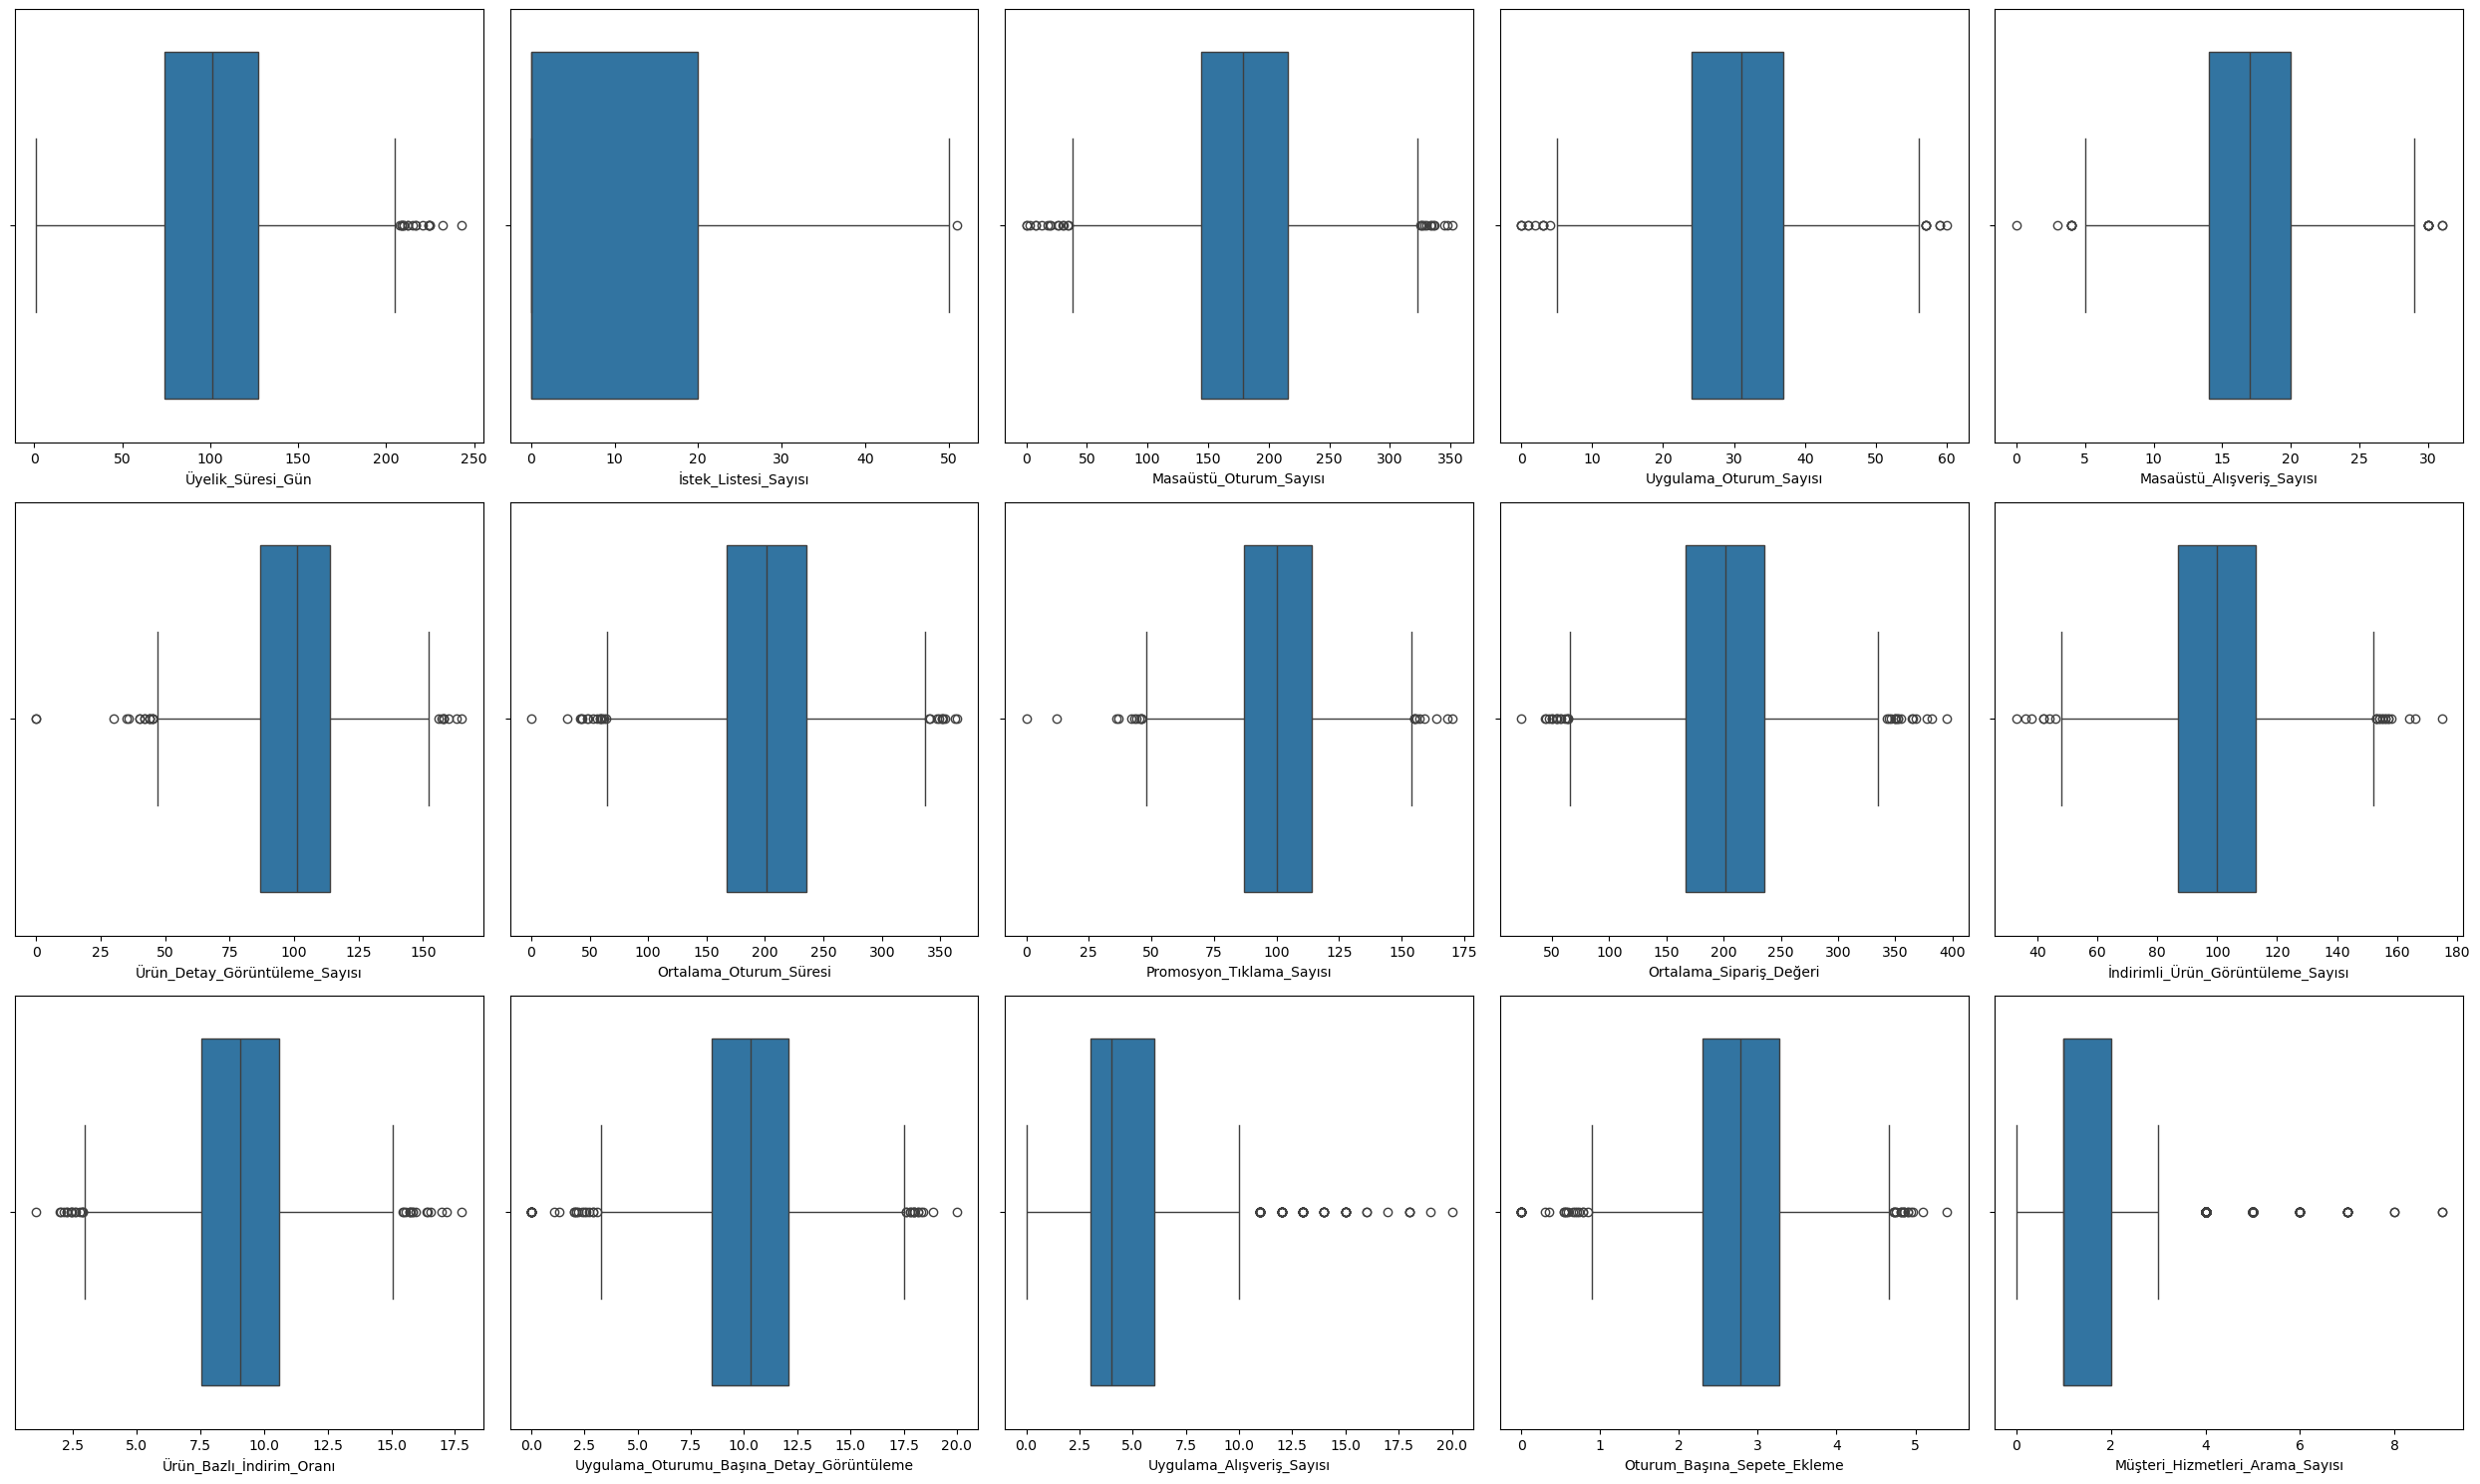

In [17]:


# Sayısal sütunlar
numeric_columns = [
    'Üyelik_Süresi_Gün', 'İstek_Listesi_Sayısı', 'Masaüstü_Oturum_Sayısı',
    'Uygulama_Oturum_Sayısı', 'Masaüstü_Alışveriş_Sayısı',
    'Ürün_Detay_Görüntüleme_Sayısı', 'Ortalama_Oturum_Süresi',
    'Promosyon_Tıklama_Sayısı', 'Ortalama_Sipariş_Değeri',
    'İndirimli_Ürün_Görüntüleme_Sayısı', 'Ürün_Bazlı_İndirim_Oranı',
    'Uygulama_Oturumu_Başına_Detay_Görüntüleme', 'Uygulama_Alışveriş_Sayısı',
    'Oturum_Başına_Sepete_Ekleme', 'Müşteri_Hizmetleri_Arama_Sayısı'
]

# Alt grafik düzeni (3 satır, 5 sütun)
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(25, 15))
axs = axs.flatten()

# Boxplot oluşturma
for i, var in enumerate(numeric_columns ):
    sns.boxplot(x=var, data=data, ax=axs[i])

# Boş kalan alt grafik eksenlerini kaldır
for j in range(len(numeric_columns ), len(axs)):
    fig.delaxes(axs[j])

# Düzeni sıkılaştır ve grafikleri göster
fig.tight_layout()
plt.show()


#### Normal dağılım(Z-skoru),göstermeyen(IQR)

In [18]:
# Normal ve normal olmayan kolonları ayırma
normal_columns = [

    'Üyelik_Süresi_Gün', 'Masaüstü_Oturum_Sayısı',
    'Uygulama_Oturum_Sayısı', 'Masaüstü_Alışveriş_Sayısı',
    'Ürün_Detay_Görüntüleme_Sayısı', 'Ortalama_Oturum_Süresi',
    'Promosyon_Tıklama_Sayısı', 'Ortalama_Sipariş_Değeri',
    'İndirimli_Ürün_Görüntüleme_Sayısı', 'Ürün_Bazlı_İndirim_Oranı',
    'Uygulama_Oturumu_Başına_Detay_Görüntüleme',
    'Oturum_Başına_Sepete_Ekleme'
]

non_normal_columns = [
     'Uygulama_Alışveriş_Sayısı', 'Müşteri_Hizmetleri_Arama_Sayısı', 'İstek_Listesi_Sayısı'
]

# Normal dağılım gösteren sütunlar için Z-skoru ile aykırı değerleri tespit etme
for column in normal_columns:
    mean = data[column].mean()
    std_dev = data[column].std()
    z_scores = (data[column] - mean) / std_dev
    threshold = 3  # Aykırı değerleri tespit etmek için z-skoru eşiği
    data = data[abs(z_scores) <= threshold]  # Aykırı değerleri çıkarma

# Normal dağılım göstermeyen sütunlar için IQR ile aykırı değerleri tespit etme
for column in non_normal_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)  # Aykırı değerleri sınırlama




Normal Kolonlar İçin Kutu Grafikleri:


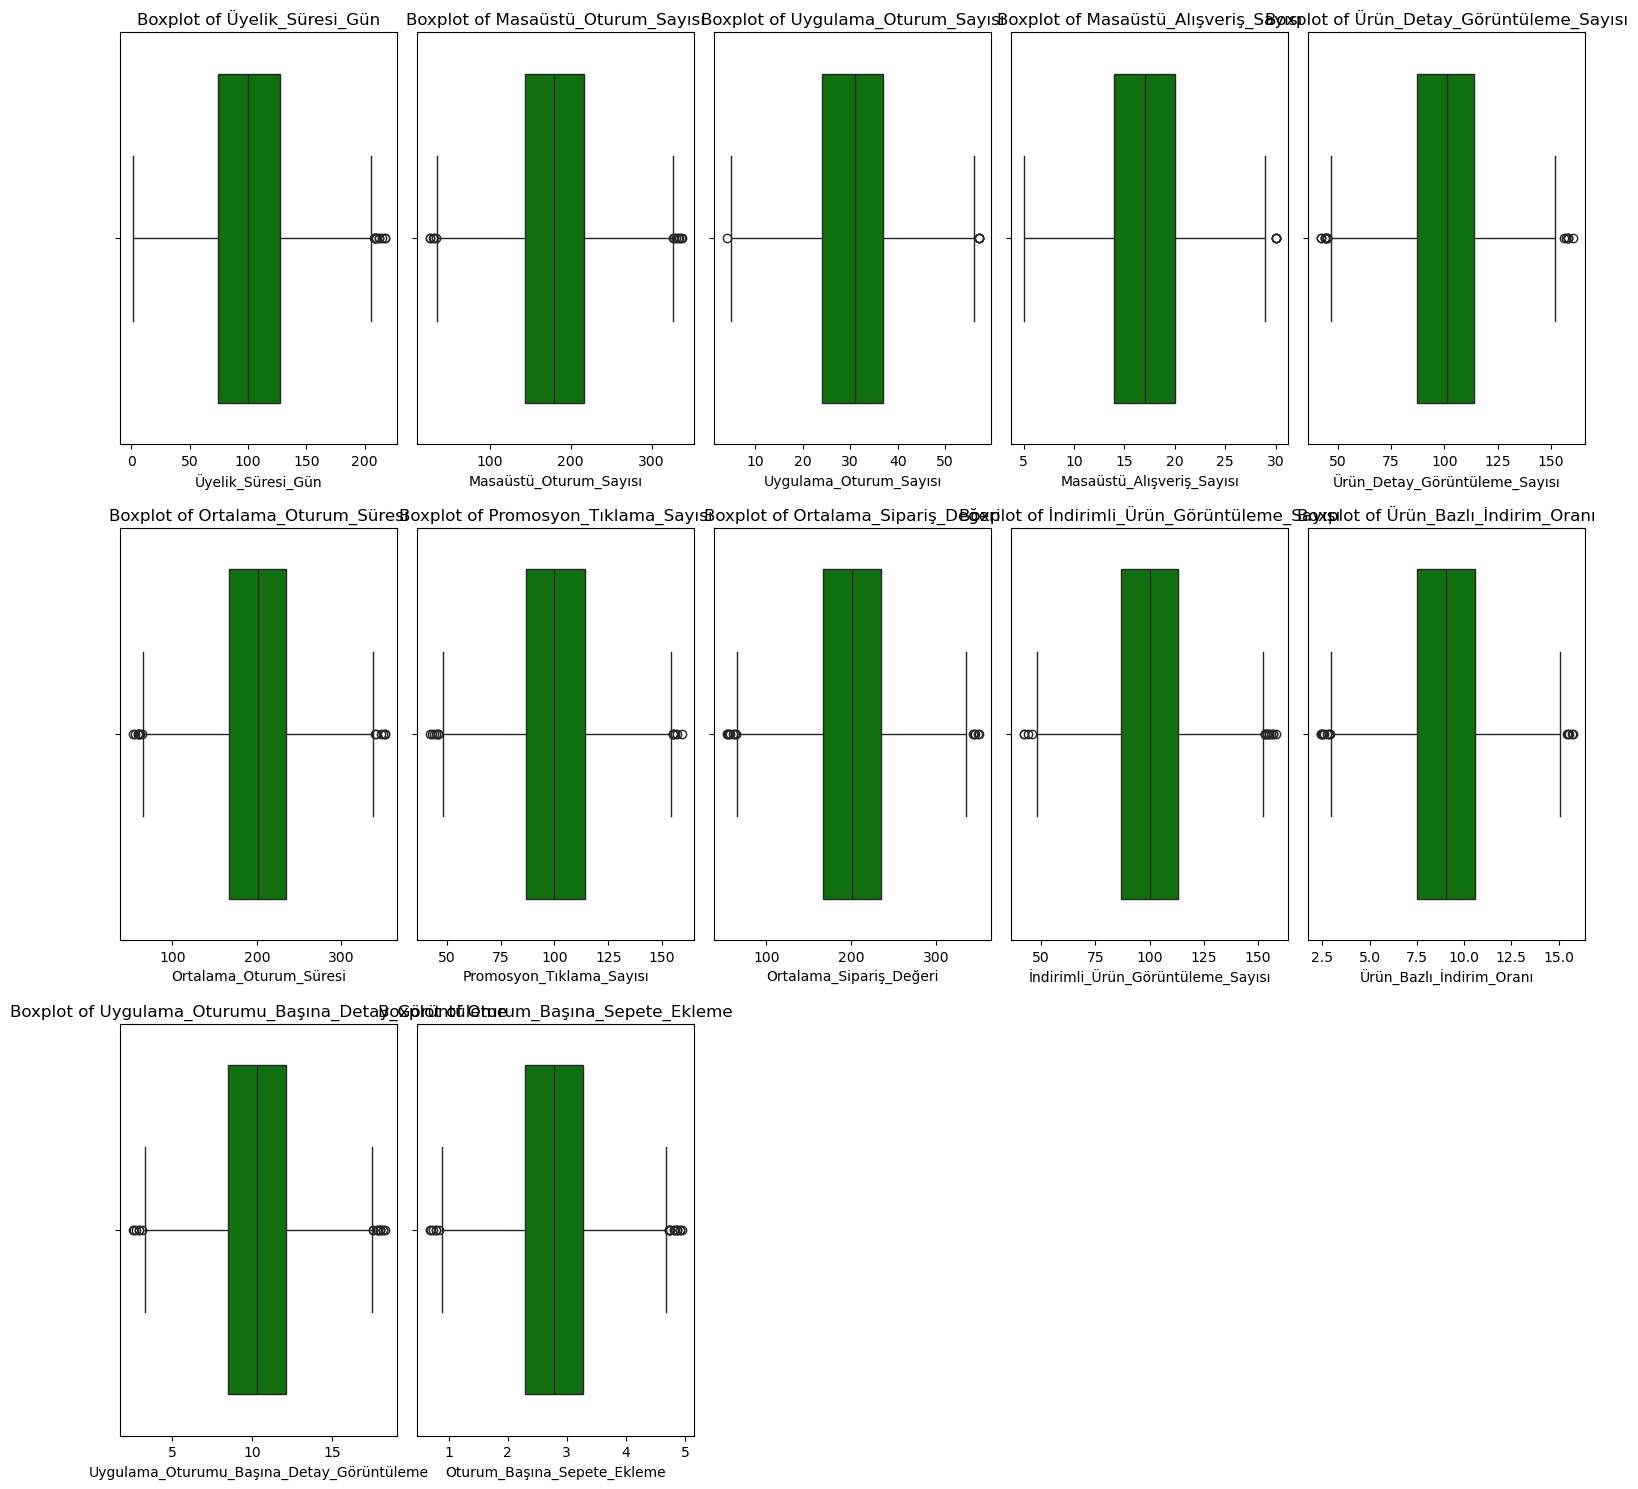

Non-Normal Kolonlar İçin Kutu Grafikleri:


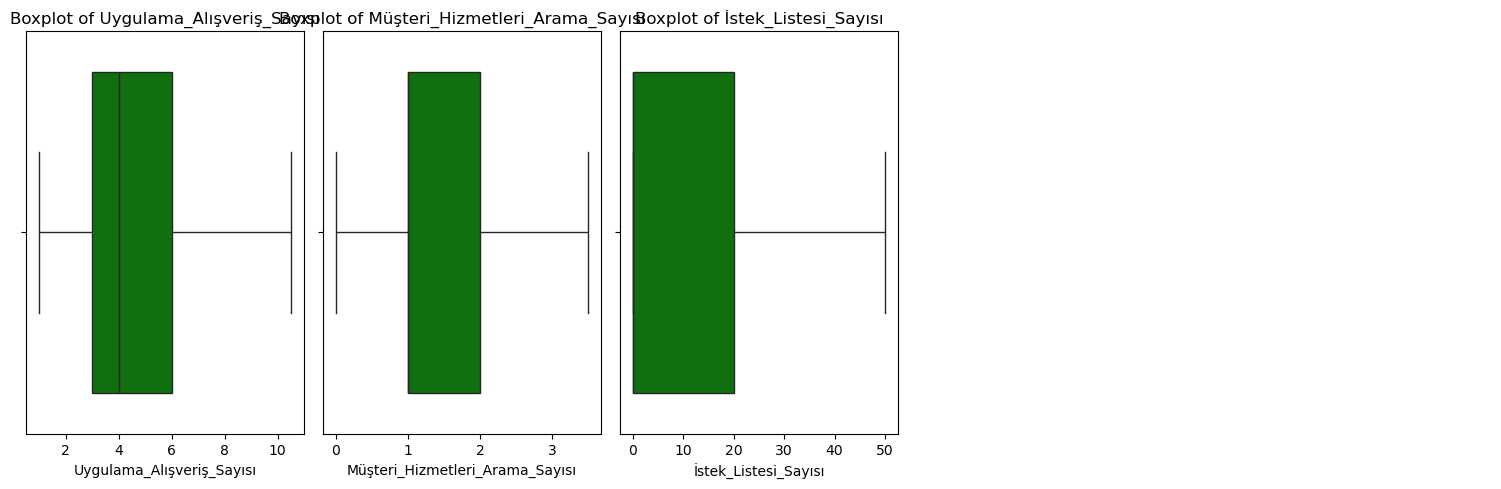

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplots(data, columns):
    n_cols = 5  # 5 sütun
    n_rows = (len(columns) // n_cols) + (1 if len(columns) % n_cols != 0 else 0)  # 3 satır
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))  # 15 genişlik, 5 * n_rows yükseklik
    axes = axes.flatten()  # Axes dizisini tek boyutlu hale getiriyoruz

    for i, column in enumerate(columns):
        sns.boxplot(x=data[column].dropna(), color='green', ax=axes[i])  # NaN değerleri çıkararak kutu grafiği çizme
        axes[i].set_title(f"Boxplot of {column}")
        axes[i].set_xlabel(column)

    # Eğer sütun sayısı ile satır sayısı uyumsuzsa boş alanları kaldırmak için
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()  # Alt alta sıralanacaksa daha güzel görünmesini sağlar
    plt.show()

# Normal ve Non-Normal Kolonlar İçin Kutu Grafikleri
print("Normal Kolonlar İçin Kutu Grafikleri:")
plot_boxplots(data, normal_columns)

print("Non-Normal Kolonlar İçin Kutu Grafikleri:")
plot_boxplots(data, non_normal_columns)


## Keşfisel Veri Analizi (EDA)

#### Kategorik sütunları grafiklerle analizi

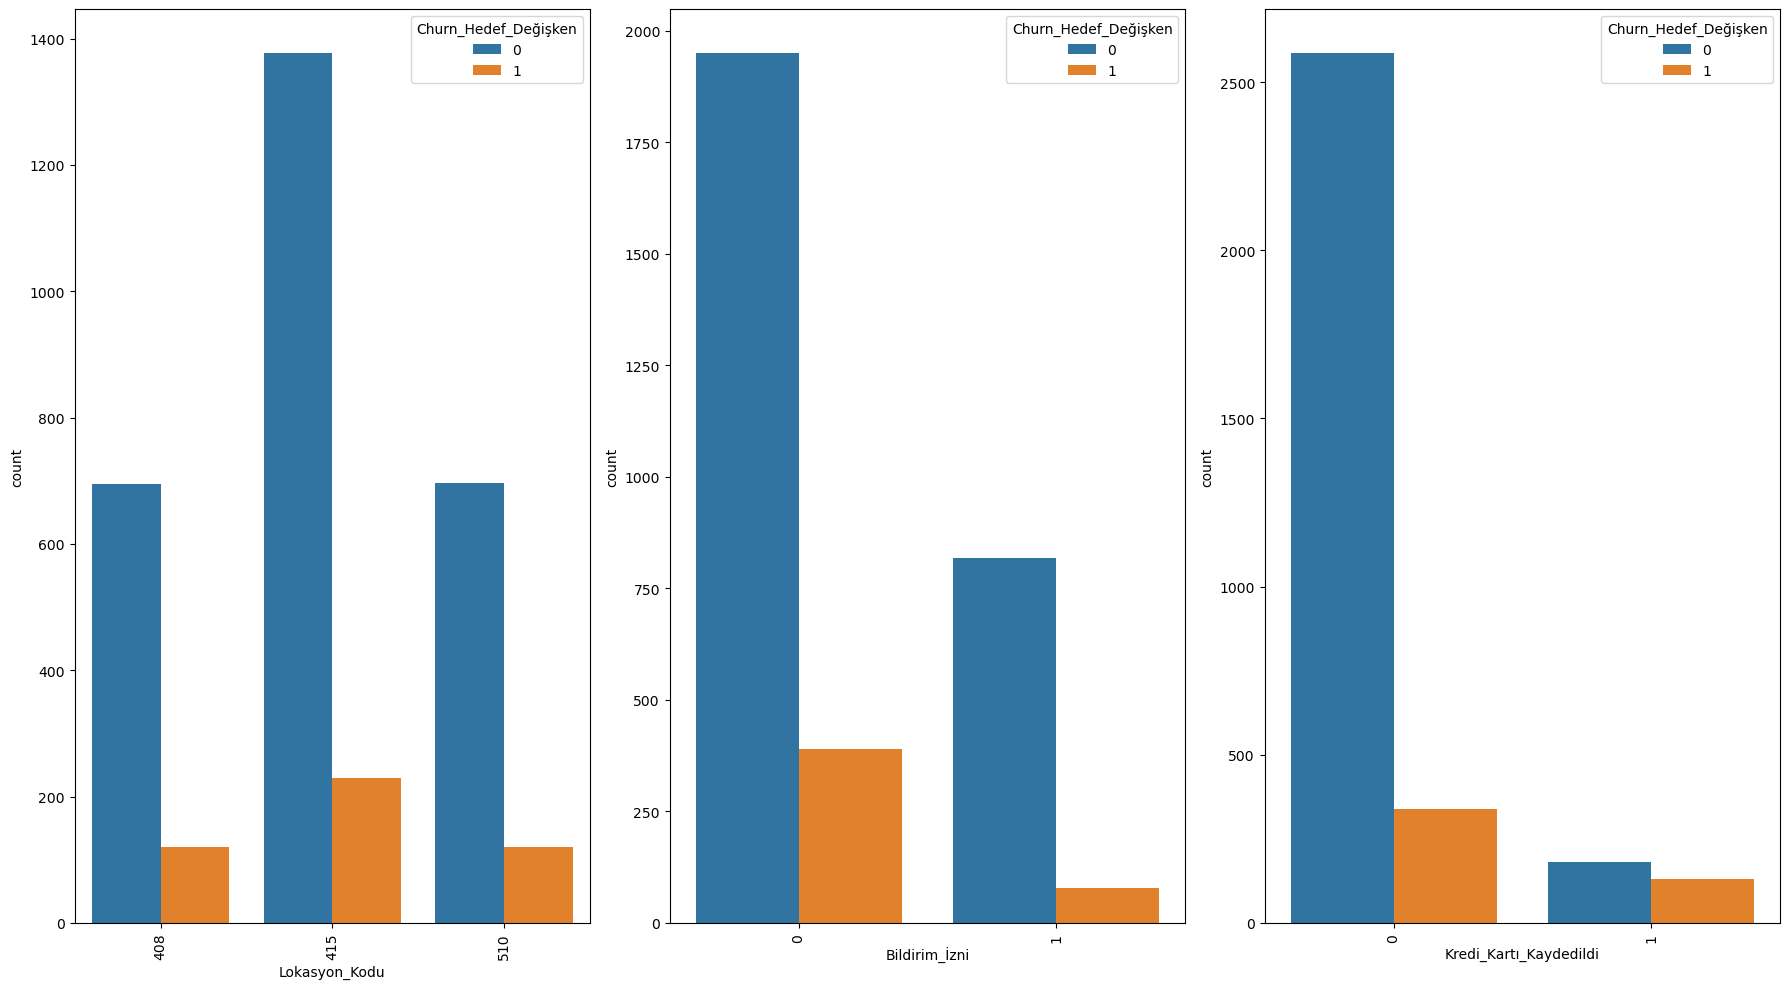

In [20]:
# list of categorical variables to plot
cat_vars = ["Lokasyon_Kodu", "Bildirim_İzni", "Kredi_Kartı_Kaydedildi"]

# create figure with subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 10))
axs = axs.flatten()

# create barplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.countplot(x=var, hue='Churn_Hedef_Değişken', data=data, ax=axs[i])
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

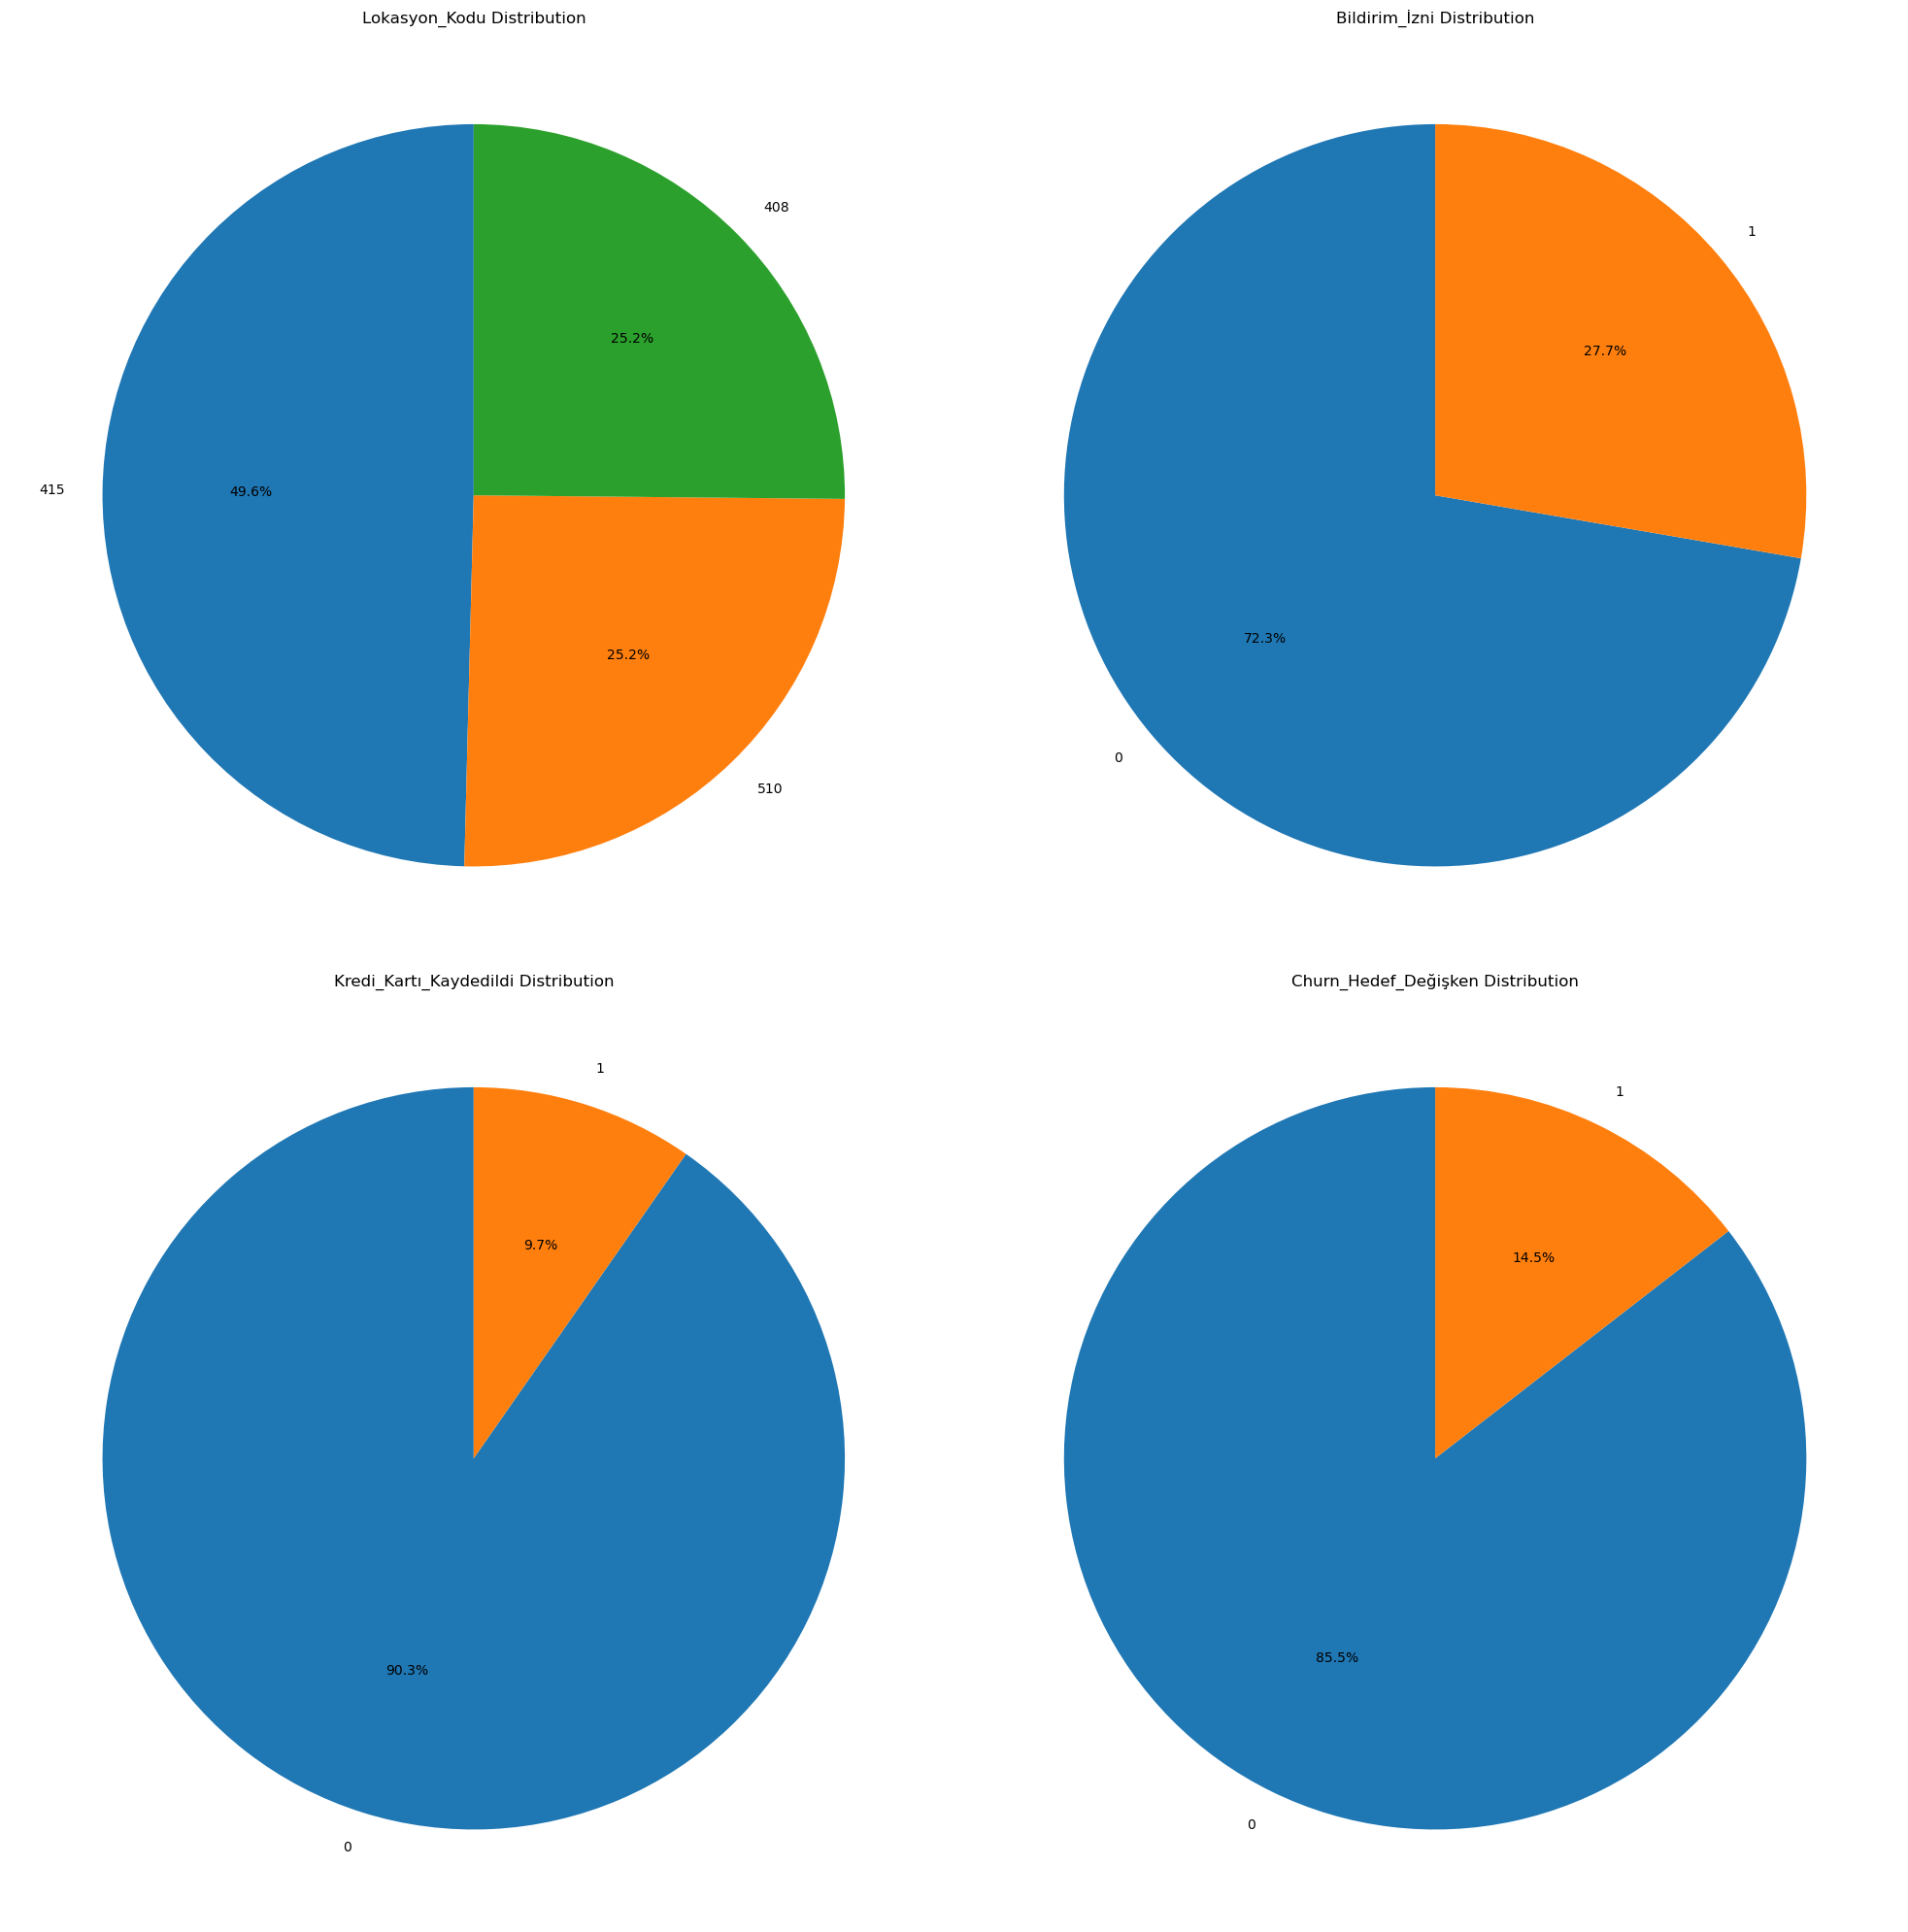

In [21]:
cat_vars = ["Lokasyon_Kodu", "Bildirim_İzni", "Kredi_Kartı_Kaydedildi","Churn_Hedef_Değişken"]

# create a figure and axes
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))

# create a pie chart for each categorical variable
for i, var in enumerate(cat_vars):
    if i < len(axs.flat):
        # count the number of occurrences for each category
        cat_counts = data[var].value_counts()

        # create a pie chart
        axs.flat[i].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)

        # set a title for each subplot
        axs.flat[i].set_title(f'{var} Distribution')

# adjust spacing between subplots
fig.tight_layout()

# show the plot
plt.show()

#### Korelasyon Matrisi

<Axes: >

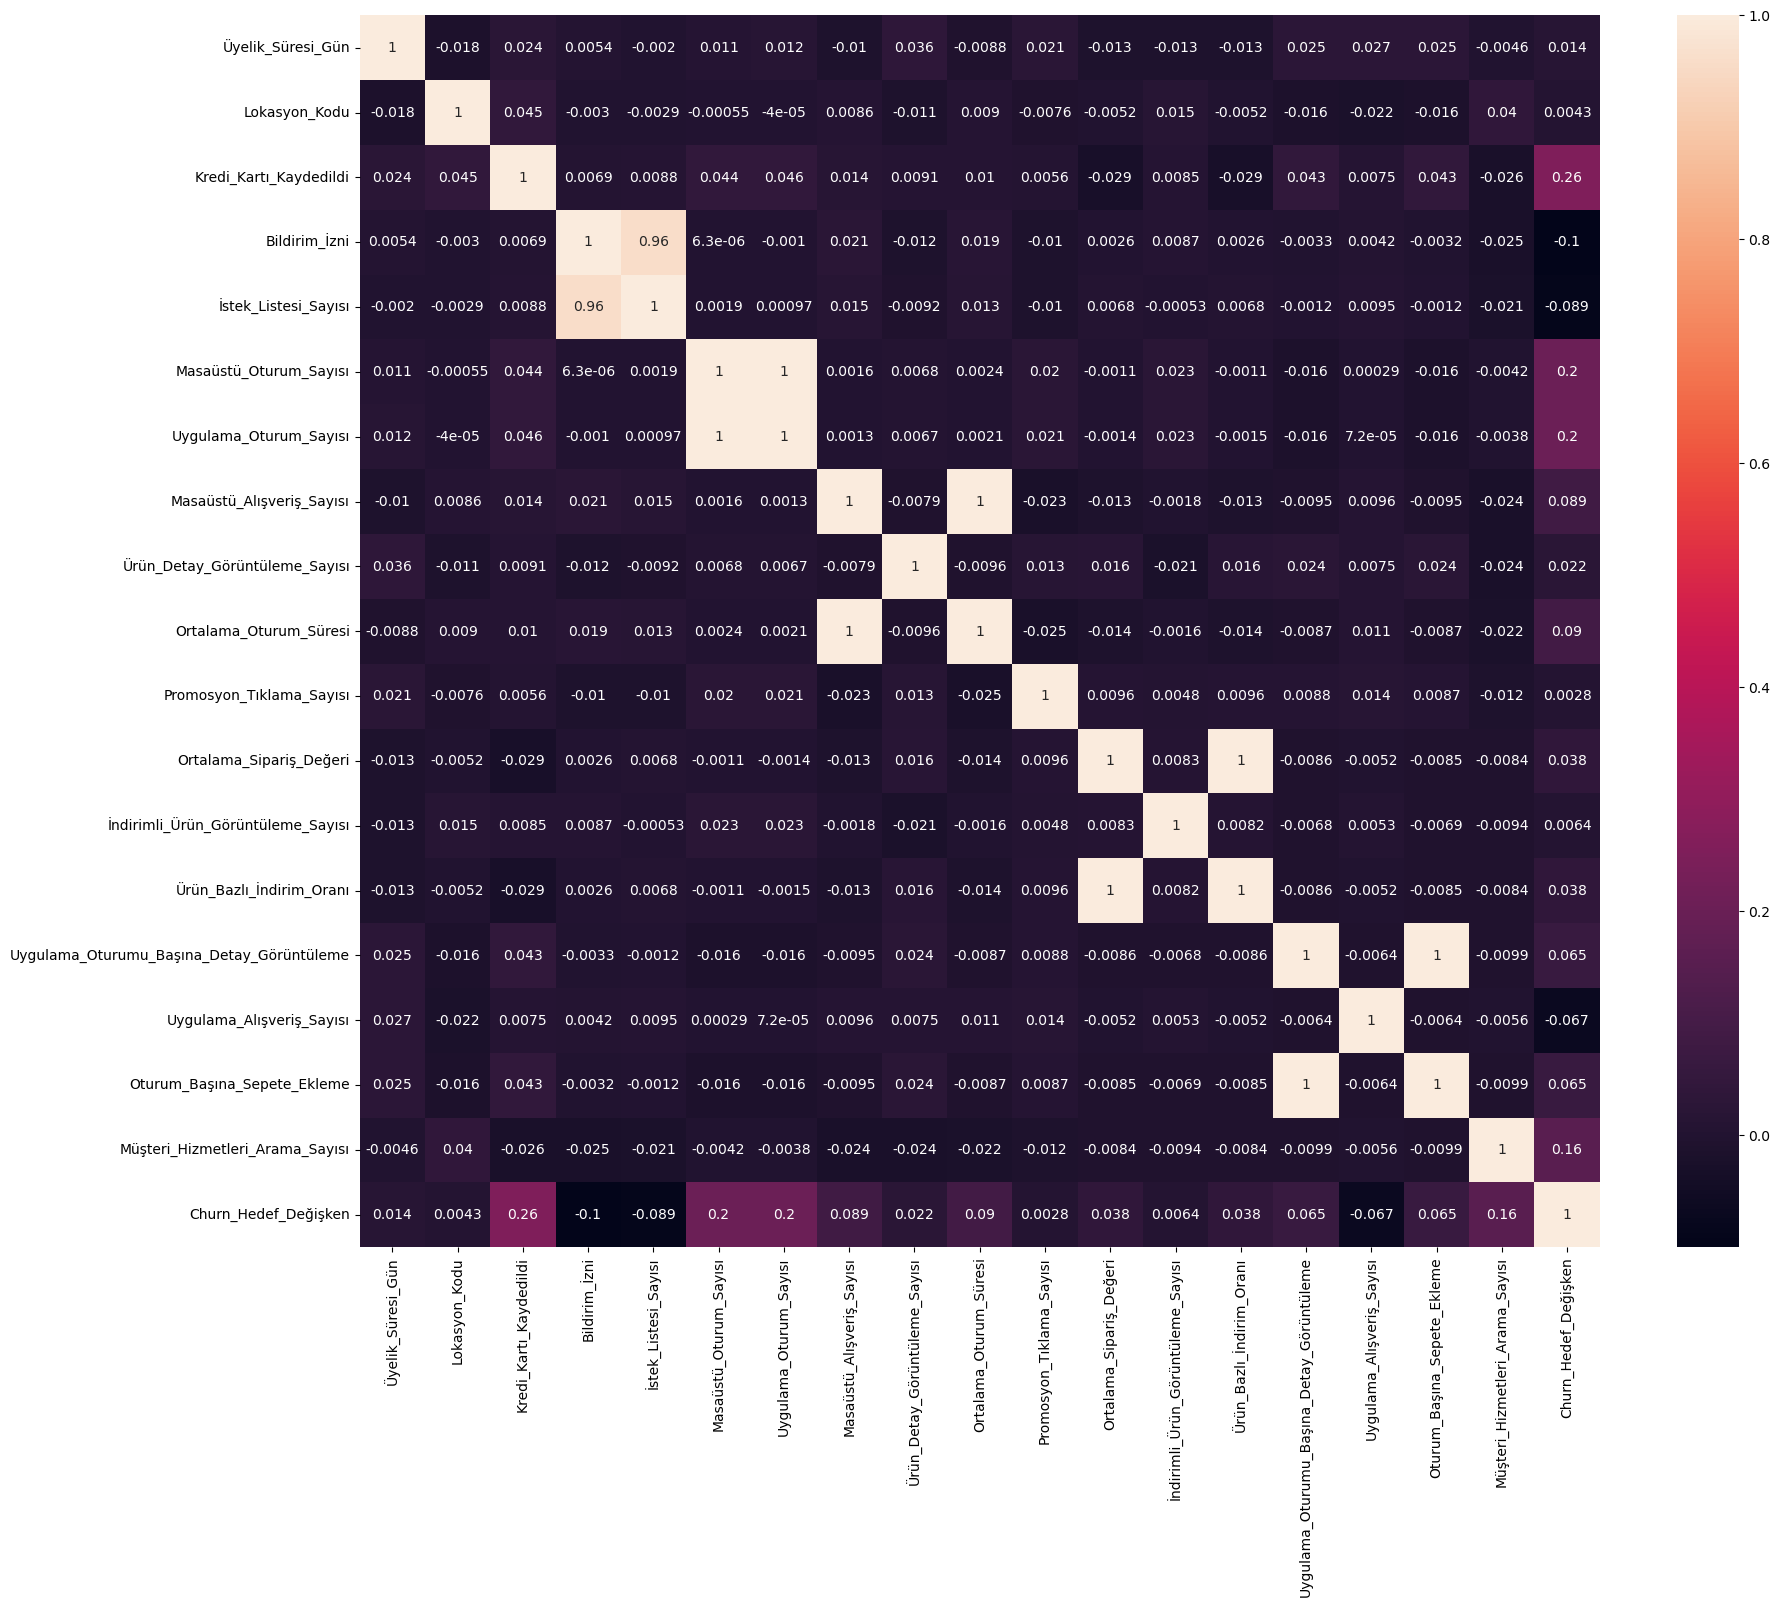

In [22]:
#Correlation Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(), fmt='.2g', annot=True)

In [23]:
# Hedef değişken adı
target_variable = "Churn_Hedef_Değişken"

# Korelasyon matrisini hesapla
correlation_matrix = data.corr()

# Hedef değişkenle korelasyonları sırala
target_corr = correlation_matrix[target_variable].drop(target_variable).sort_values(ascending=False)

# Sonuçları ekrana yazdır
print("Hedef değişkenle korelasyon:")
print(target_corr)


Hedef değişkenle korelasyon:
Kredi_Kartı_Kaydedildi                       0.256108
Masaüstü_Oturum_Sayısı                       0.203376
Uygulama_Oturum_Sayısı                       0.202876
Müşteri_Hizmetleri_Arama_Sayısı              0.156279
Ortalama_Oturum_Süresi                       0.089746
Masaüstü_Alışveriş_Sayısı                    0.088676
Oturum_Başına_Sepete_Ekleme                  0.065184
Uygulama_Oturumu_Başına_Detay_Görüntüleme    0.065158
Ürün_Bazlı_İndirim_Oranı                     0.037505
Ortalama_Sipariş_Değeri                      0.037502
Ürün_Detay_Görüntüleme_Sayısı                0.021775
Üyelik_Süresi_Gün                            0.013868
İndirimli_Ürün_Görüntüleme_Sayısı            0.006355
Lokasyon_Kodu                                0.004338
Promosyon_Tıklama_Sayısı                     0.002825
Uygulama_Alışveriş_Sayısı                   -0.067096
İstek_Listesi_Sayısı                        -0.088892
Bildirim_İzni                               -0.100380

In [24]:
# Çok yüksek korelasyona sahip sütun çiftlerini belirleme
high_corr_pairs = []
threshold = 0.85  # Yüksek korelasyon eşiği

# Yeni korelasyon matrisi üzerinden işlem
for col in correlation_matrix.columns:
    for row in correlation_matrix.columns:
        if col != row and abs(correlation_matrix.loc[col, row]) > threshold:
            high_corr_pairs.append((col, row, correlation_matrix.loc[col, row]))

# Çok yüksek korelasyona sahip sütun çiftlerini yazdır
print("\nÇok yüksek korelasyona sahip sütun çiftleri:")
for pair in high_corr_pairs:
    print(f"{pair[0]} ve {pair[1]}: Korelasyon = {pair[2]:.2f}")



Çok yüksek korelasyona sahip sütun çiftleri:
Bildirim_İzni ve İstek_Listesi_Sayısı: Korelasyon = 0.96
İstek_Listesi_Sayısı ve Bildirim_İzni: Korelasyon = 0.96
Masaüstü_Oturum_Sayısı ve Uygulama_Oturum_Sayısı: Korelasyon = 1.00
Uygulama_Oturum_Sayısı ve Masaüstü_Oturum_Sayısı: Korelasyon = 1.00
Masaüstü_Alışveriş_Sayısı ve Ortalama_Oturum_Süresi: Korelasyon = 1.00
Ortalama_Oturum_Süresi ve Masaüstü_Alışveriş_Sayısı: Korelasyon = 1.00
Ortalama_Sipariş_Değeri ve Ürün_Bazlı_İndirim_Oranı: Korelasyon = 1.00
Ürün_Bazlı_İndirim_Oranı ve Ortalama_Sipariş_Değeri: Korelasyon = 1.00
Uygulama_Oturumu_Başına_Detay_Görüntüleme ve Oturum_Başına_Sepete_Ekleme: Korelasyon = 1.00
Oturum_Başına_Sepete_Ekleme ve Uygulama_Oturumu_Başına_Detay_Görüntüleme: Korelasyon = 1.00


In [25]:
# Öznitelik seçimi: hedef değişkenle düşük korelasyonlu sütunları ele
low_corr_threshold = 0.1  # Düşük korelasyon eşiği

# Hedef değişkenle düşük korelasyona sahip olmayan sütunları seç
selected_features = [
    feature for feature in correlation_matrix.columns
    if feature != target_variable and abs(target_corr[feature]) >= low_corr_threshold
]

print("Düşük korelasyonlu sütunlar çıkarıldı, seçilen sütunlar:")
print(selected_features)


Düşük korelasyonlu sütunlar çıkarıldı, seçilen sütunlar:
['Kredi_Kartı_Kaydedildi', 'Bildirim_İzni', 'Masaüstü_Oturum_Sayısı', 'Uygulama_Oturum_Sayısı', 'Müşteri_Hizmetleri_Arama_Sayısı']


In [26]:
# Hedef değişkenle korelasyonu ve yüksek korelasyonlu sütunları dikkate alarak seçim yap
columns_to_drop = set()

# Yüksek korelasyonlu sütun çiftlerini değerlendir
for col1, col2, corr in high_corr_pairs:
    # Hedef değişkenle korelasyona bakarak daha düşük olanı çıkar
    if abs(target_corr[col1]) < abs(target_corr[col2]):
        columns_to_drop.add(col1)
    else:
        columns_to_drop.add(col2)

# Seçilen sütunları güncelle (yüksek korelasyona sahip olanlar hariç)
selected_columns = [col for col in correlation_matrix.columns if col != target_variable and col not in columns_to_drop]

# Sonuçları yazdır
print("Elenen sütunlar:", columns_to_drop)
print("Seçilen sütunlar:", selected_columns)


Elenen sütunlar: {'Masaüstü_Alışveriş_Sayısı', 'Uygulama_Oturum_Sayısı', 'Uygulama_Oturumu_Başına_Detay_Görüntüleme', 'İstek_Listesi_Sayısı', 'Ortalama_Sipariş_Değeri'}
Seçilen sütunlar: ['Üyelik_Süresi_Gün', 'Lokasyon_Kodu', 'Kredi_Kartı_Kaydedildi', 'Bildirim_İzni', 'Masaüstü_Oturum_Sayısı', 'Ürün_Detay_Görüntüleme_Sayısı', 'Ortalama_Oturum_Süresi', 'Promosyon_Tıklama_Sayısı', 'İndirimli_Ürün_Görüntüleme_Sayısı', 'Ürün_Bazlı_İndirim_Oranı', 'Uygulama_Alışveriş_Sayısı', 'Oturum_Başına_Sepete_Ekleme', 'Müşteri_Hizmetleri_Arama_Sayısı']


In [27]:

X = data[selected_columns]  # Sayısal ve kategorik sütunlar
y = data["Churn_Hedef_Değişken"]  # Hedef değişken


## Modelleme ve Performans Değerlendirmesi

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#### Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {"criterion": ("entropy", "gini"), #Karar ağacının düğümlerini bölmek için kullanılacak ölçütü belirler. Saikia kullansian k
            "splitter":("best", "random"), #karar ağacının düğümlerini bölme stratejisini belirler.
            "max_depth": (list(range(1, 10))), #Oluşturulacak olan ağacın maksimum derinliğini belirler.Bu parametre, ağacın asıra öğrenme veya ezberleme
            "min_samples_split":[2, 3, 4], #Bir düğümün bölünmesi için gereken minimum örnek sayısına belirler.
            "min_samples_leaf": list (range(1, 10)) #Bir yaprak düğümü oluşturmak için gerekli olan minimum örnek sayısını belirler.
            }
# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}


In [29]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(**grid_search.best_params_)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_leaf=2)

In [30]:
from sklearn.metrics import accuracy_score
y_pred = dtree.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 94.03 %


In [31]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, log_loss
print('F-1 Score : ',(f1_score(y_test, y_pred, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred, average='micro')))
print('Jaccard Score : ',(jaccard_score(y_test, y_pred, average='micro')))
print('Log Loss : ',(log_loss(y_test, y_pred)))

F-1 Score :  0.9403292181069959
Precision Score :  0.9403292181069959
Recall Score :  0.9403292181069959
Jaccard Score :  0.887378640776699
Log Loss :  2.150752980009048


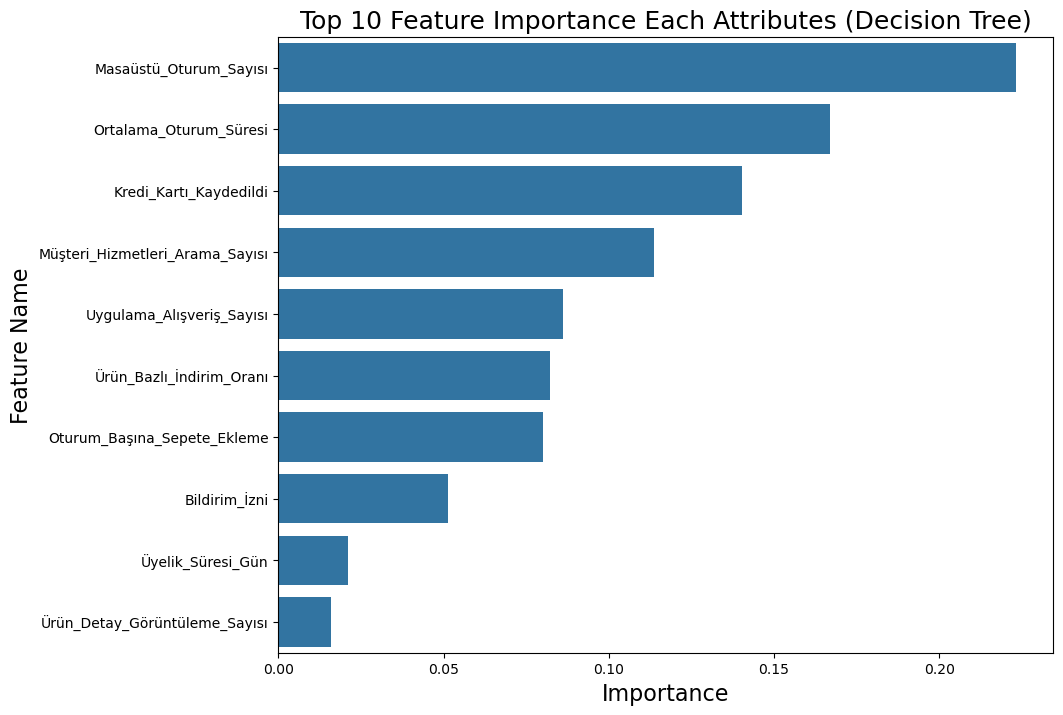

In [32]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": dtree.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

Text(0.5, 1.0, 'Accuracy Score for Decision Tree: 0.9403292181069959')

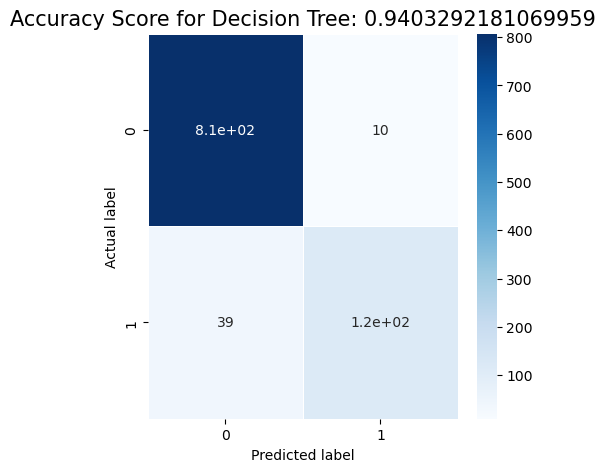

In [43]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True,  cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for Decision Tree: {0}'.format(dtree.score(X_test, y_test))
plt.title(all_sample_title, size = 15)

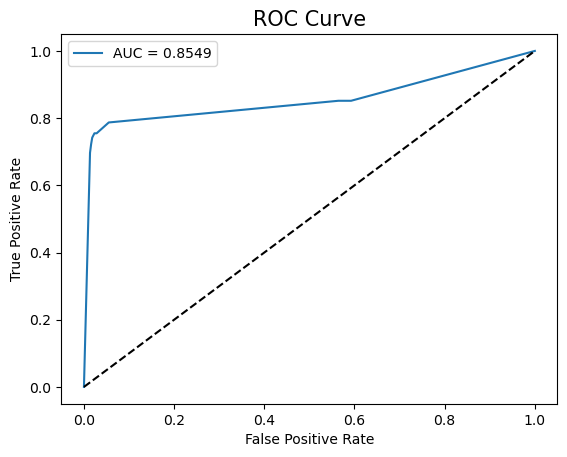

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = dtree.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

#### Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rfc = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'random_state': [0, 42]
}

# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(rfc, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': None, 'max_features': None, 'n_estimators': 100, 'random_state': 42}


In [36]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(**grid_search.best_params_)
rfc.fit(X_train, y_train)

RandomForestClassifier(max_features=None, random_state=42)

In [37]:
y_pred = rfc.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 94.96 %


In [38]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, log_loss
print('F-1 Score : ',(f1_score(y_test, y_pred, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred, average='micro')))
print('Jaccard Score : ',(jaccard_score(y_test, y_pred, average='micro')))
print('Log Loss : ',(log_loss(y_test, y_pred)))

F-1 Score :  0.9495884773662552
Precision Score :  0.9495884773662552
Recall Score :  0.9495884773662552
Jaccard Score :  0.9040156709108716
Log Loss :  1.8170154486283336


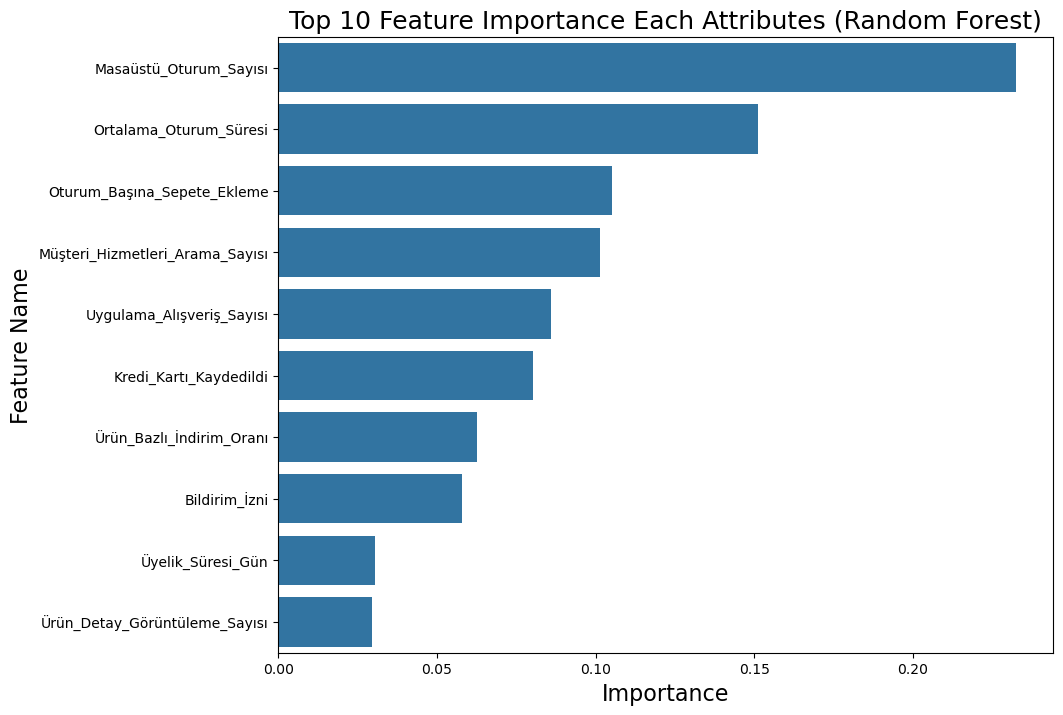

In [39]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": rfc.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Random Forest)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

Text(0.5, 1.0, 'Accuracy Score for Random Forest: 0.9495884773662552')

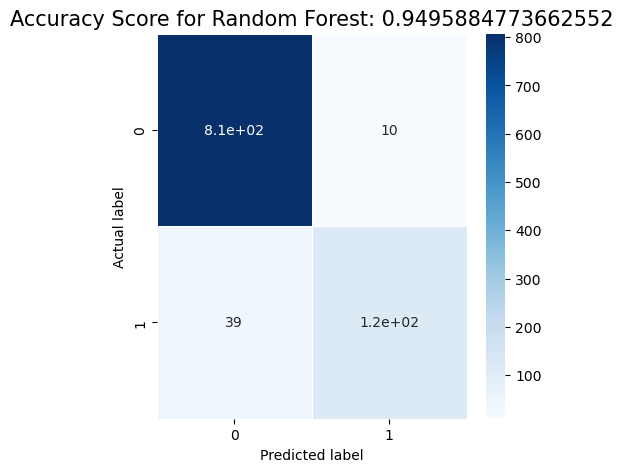

In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True,  cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for Random Forest: {0}'.format(rfc.score(X_test, y_test))
plt.title(all_sample_title, size = 15)

In [1]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = rfc.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

NameError: name 'rfc' is not defined

#### XGBoost

In [42]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Create an XGBoost classifier
xgb = XGBClassifier()

# Define the parameter grid for grid search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'gamma': [0, 0.1, 0.2]
}

# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(xgb, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [45]:
from xgboost import XGBClassifier
xgb = XGBClassifier(gamma=0, learning_rate=0.1, max_depth=7, n_estimators=200)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [46]:
from sklearn.metrics import accuracy_score
y_pred = xgb.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 94.96 %


In [47]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, log_loss
print('F-1 Score : ',(f1_score(y_test, y_pred, average='micro')))
print('Precision Score : ',(precision_score(y_test, y_pred, average='micro')))
print('Recall Score : ',(recall_score(y_test, y_pred, average='micro')))
print('Jaccard Score : ',(jaccard_score(y_test, y_pred, average='micro')))
print('Log Loss : ',(log_loss(y_test, y_pred)))

F-1 Score :  0.9495884773662552
Precision Score :  0.9495884773662552
Recall Score :  0.9495884773662552
Jaccard Score :  0.9040156709108716
Log Loss :  1.817015448628334


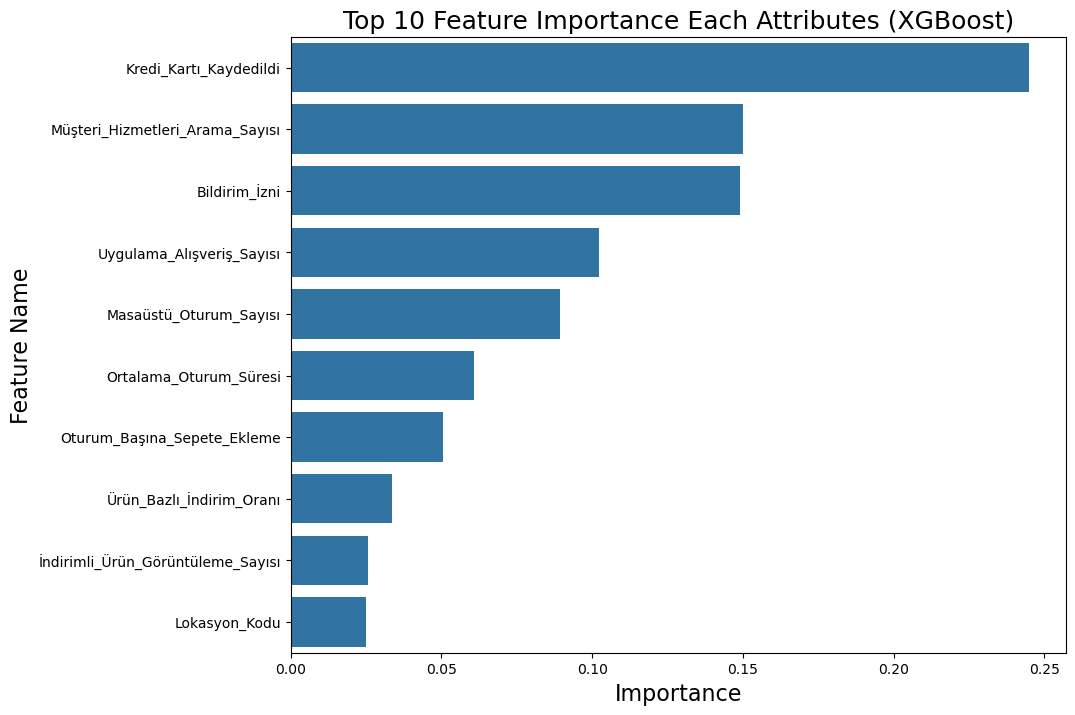

In [48]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": xgb.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (XGBoost)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

Text(0.5, 1.0, 'Accuracy Score for XGBoost: 0.9495884773662552')

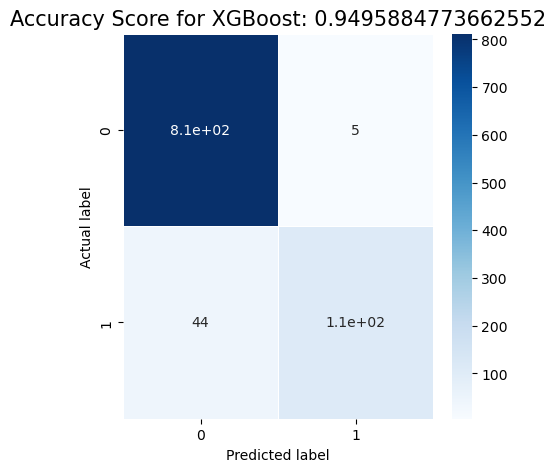

In [49]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True,  cmap = 'Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for XGBoost: {0}'.format(xgb.score(X_test, y_test))
plt.title(all_sample_title, size = 15)

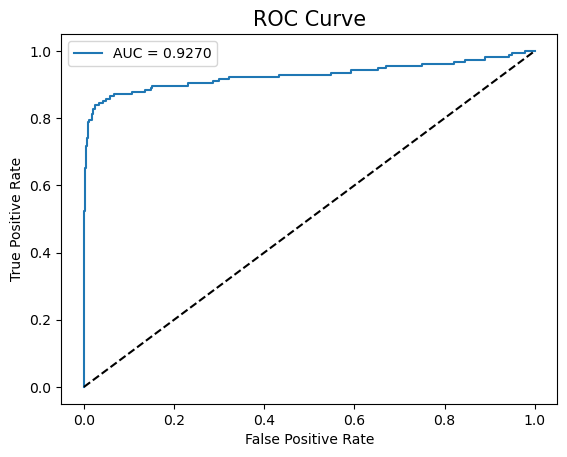

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = xgb.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, jaccard_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Logistic Regression Model
lr = LogisticRegression(class_weight='balanced', solver='liblinear')

# Parametre grid'ini belirleme
param_grid = {
    'C': [0.1, 1, 10],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'random_state': [0, 42]
}

# Grid Search Cross-Validation ile en iyi hiperparametreleri bulma
grid_search = GridSearchCV(lr, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# En iyi hiperparametreleri yazdırma
print(grid_search.best_params_)

{'C': 10, 'penalty': 'l1', 'random_state': 0}


In [30]:
# Logistic Regression modelini en iyi parametrelerle eğitme
lr = LogisticRegression(**grid_search.best_params_, solver='liblinear')
lr.fit(X_train, y_train)

LogisticRegression(C=10, penalty='l1', random_state=0, solver='liblinear')

In [33]:
# Tahmin yapma
y_pred = lr.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 84.47 %


In [34]:
# Performans metriklerini yazdırma
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")
print('F-1 Score : ', (f1_score(y_test, y_pred, average='micro')))
print('Precision Score : ', (precision_score(y_test, y_pred, average='micro')))
print('Recall Score : ', (recall_score(y_test, y_pred, average='micro')))
print('Jaccard Score : ', (jaccard_score(y_test, y_pred, average='micro')))
print('Log Loss : ', (log_loss(y_test, y_pred)))

Accuracy Score : 84.47 %
F-1 Score :  0.8446502057613169
Precision Score :  0.8446502057613169
Recall Score :  0.8446502057613169
Jaccard Score :  0.7310774710596616
Log Loss :  5.599374137609763


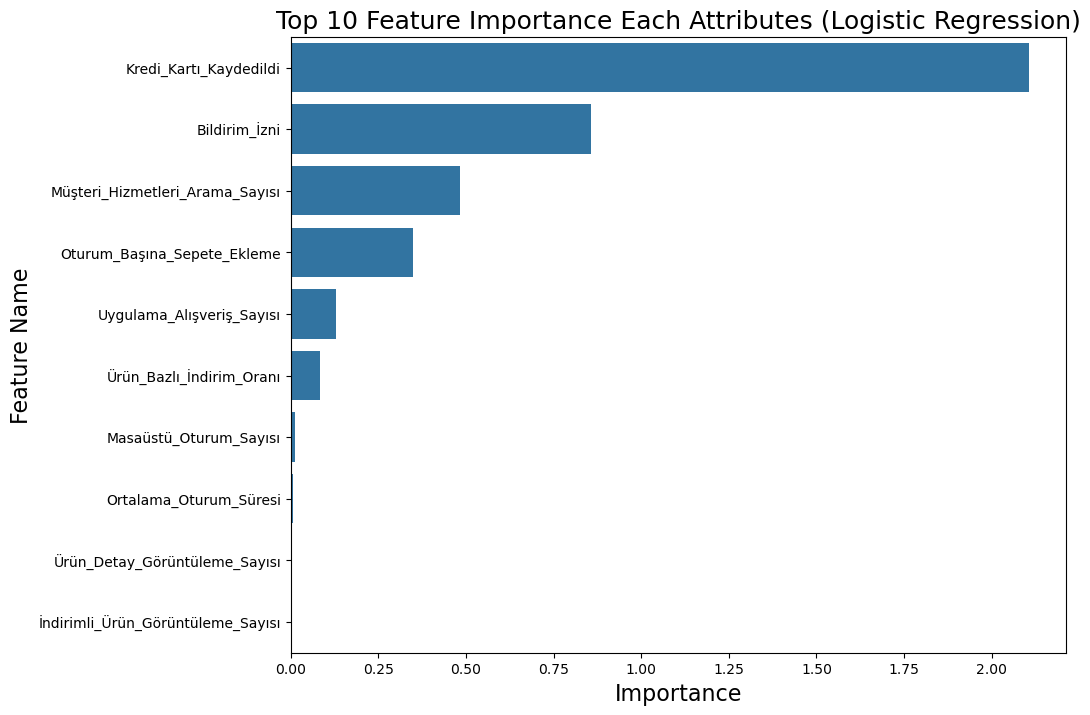

In [35]:
# Özelliklerin önemini görselleştirme
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": np.abs(lr.coef_[0])  # Logistic Regression'da coef_ parametresi ile özelliklerin etkisi alınır
})

fi = imp_df.sort_values(by="Importance", ascending=False)
fi2 = fi.head(10)

plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Logistic Regression)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

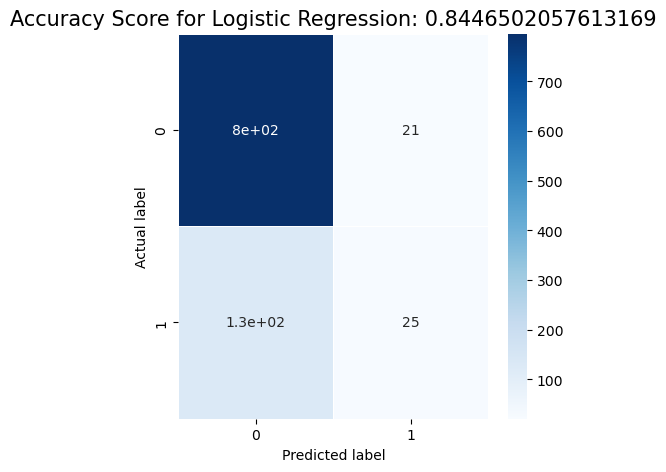

In [36]:
# Confusion Matrix'i hesaplayıp görselleştirme
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidths=.5, annot=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
all_sample_title = 'Accuracy Score for Logistic Regression: {0}'.format(lr.score(X_test, y_test))
plt.title(all_sample_title, size=15)
plt.show()

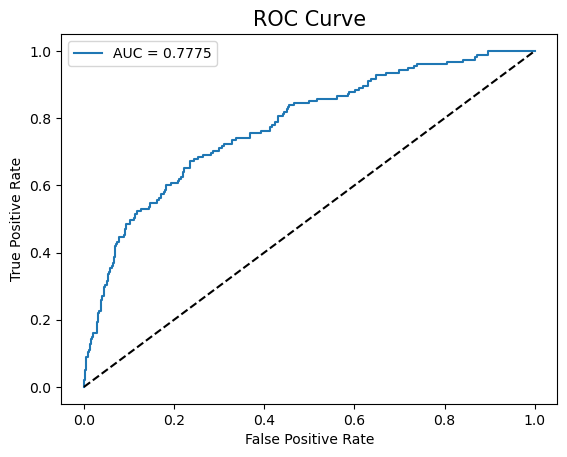

In [37]:
# ROC Curve hesaplama ve görselleştirme
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = lr.predict_proba(X_test)[:, 1]  # Pozitif sınıfın olasılığı

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), 
                                 pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' % auc)
plt.plot(fpr, fpr, linestyle='--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size=15)
plt.legend()
plt.show()